# Results Analysis & Visualization

This notebook visualizes the different models from Notebook 3, and creates plots comparing the data for structural features and GroupKFolds.

## Steps
1. Load trained models and predictions
2. Find the best model
3. Visualize model comparrisons
5. Dataset visualization
6. Summary table of model comparrison
7. Random vs GroupKFold comparison with and without structural features
8. Importances plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_palette("husl")

# Define data directory
DATA_DIR = Path('../data')

print("Results Visualization Notebook")
print("=" * 50)

Results Visualization Notebook


## Load Results

In [2]:
# Load model results
df_cv_results = pd.read_csv(DATA_DIR / 'stability_classification_results.csv')

print("=== MODEL CROSS-VALIDATION RESULTS ===\n")
print(df_cv_results.to_string(index=False))

=== MODEL CROSS-VALIDATION RESULTS ===

                  Model  Test_Accuracy  Test_F1  Test_AUC  Test_Precision  Test_Recall
    Logistic Regression       0.784815 0.211211  0.586066        0.157348     0.403333
Random Forest (Shallow)       0.899274 0.295556  0.704570        0.308571     0.330000
 Random Forest (Medium)       0.913188 0.173810  0.711354        0.183333     0.173333
      Gradient Boosting       0.899395 0.203175  0.694247        0.366667     0.163333


## Model Comparrison Visualization

/var/folders/w3/4y_6p1q92gjg9dwqq9vfgqww0000gn/T/ipykernel_96683/1677891084.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


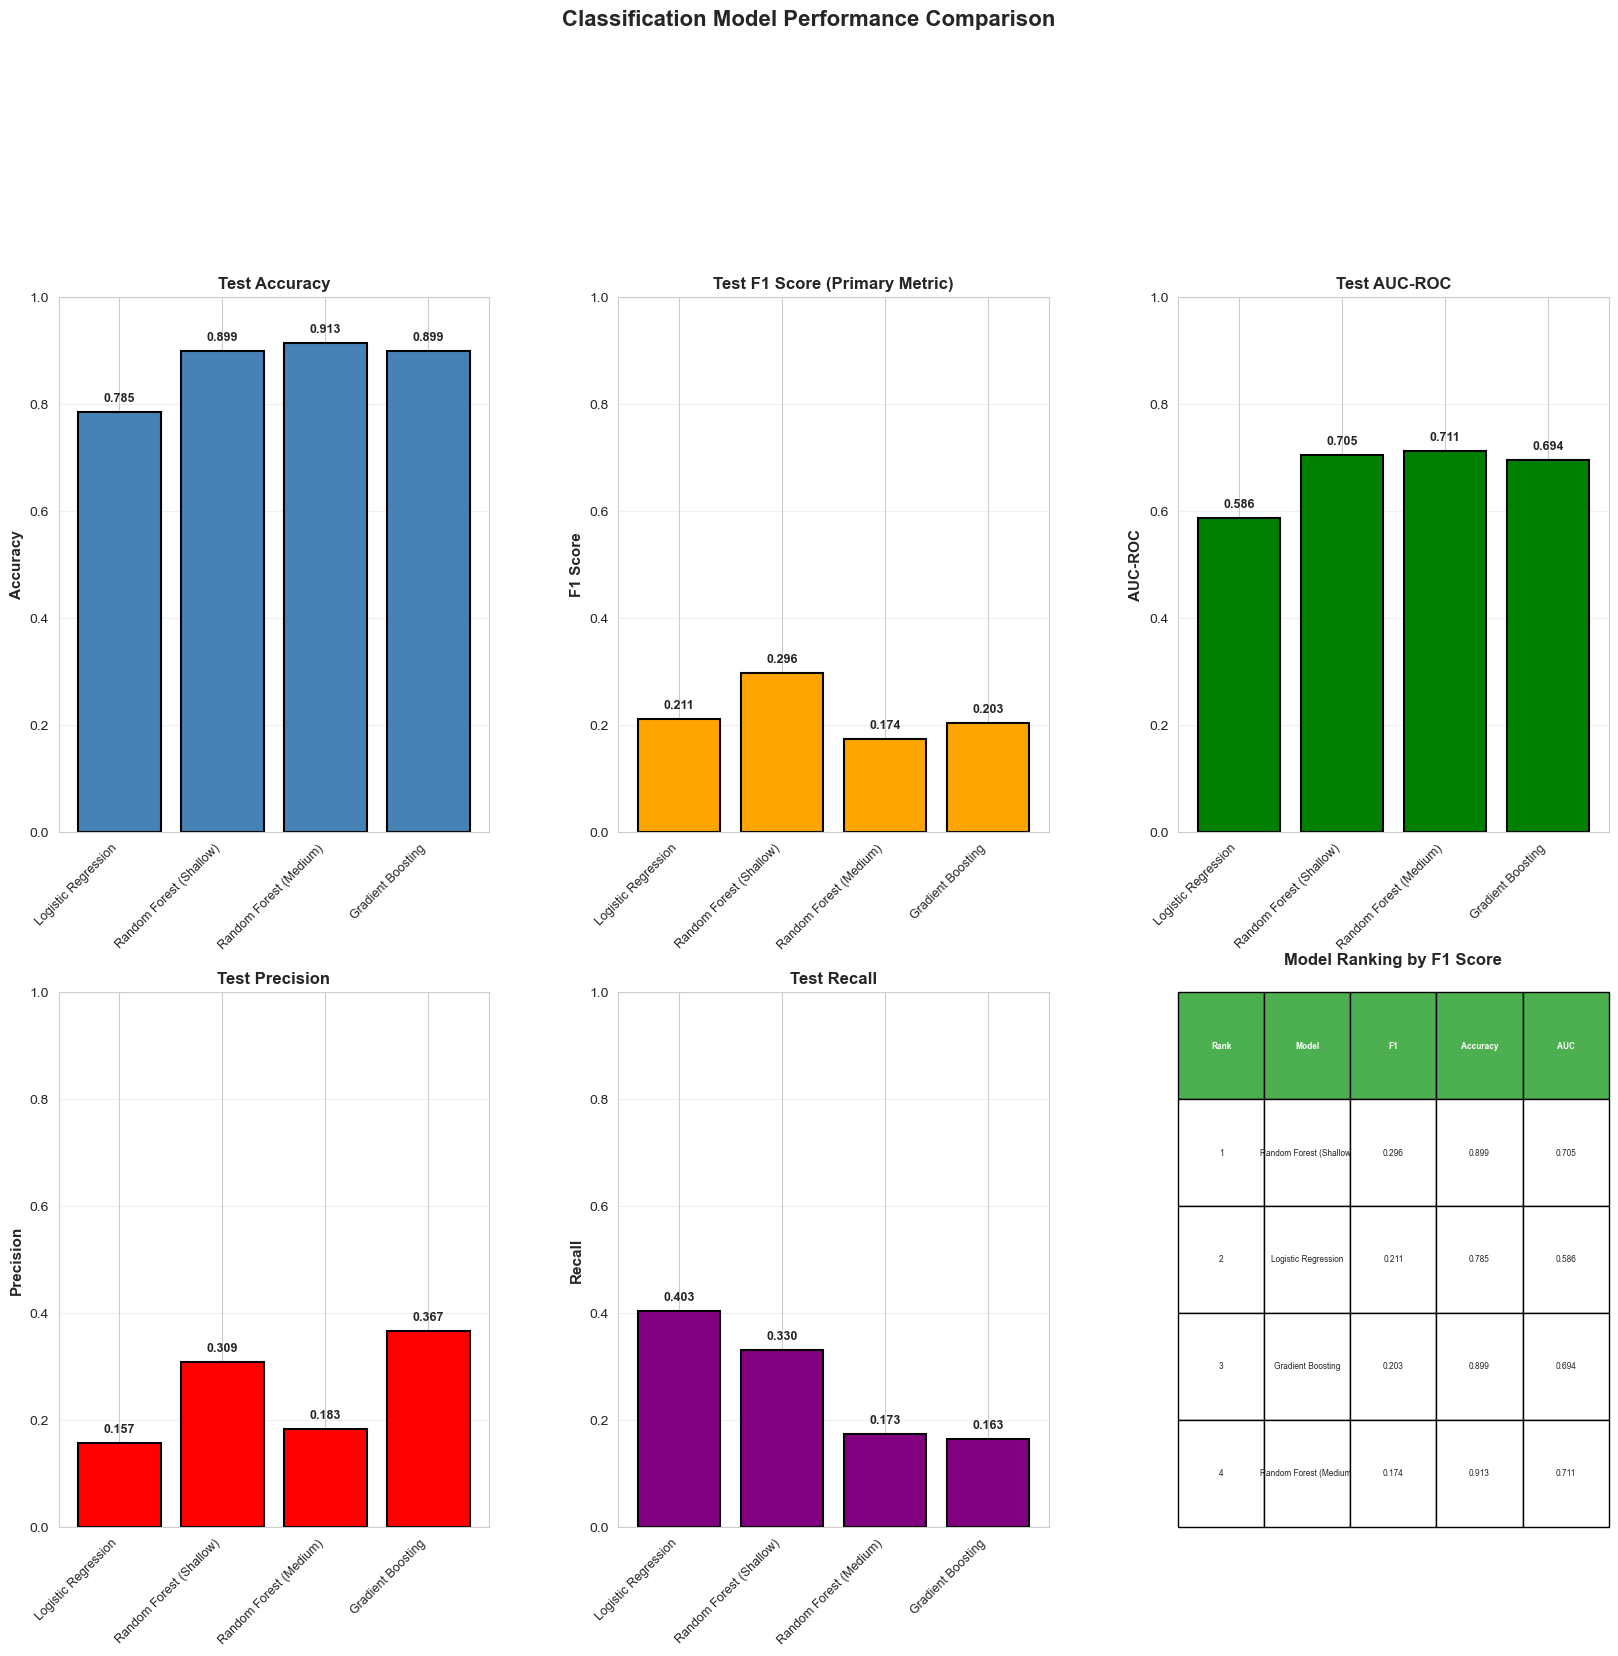

In [3]:
fig = plt.figure(figsize=(20, 25))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

metrics = ['Test_Accuracy', 'Test_F1', 'Test_AUC', 'Test_Precision', 'Test_Recall']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. Accuracy
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(df_cv_results)), df_cv_results['Test_Accuracy'], 
               color='steelblue', edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Test Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(df_cv_results)))
ax1.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 2. F1 Score
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(range(len(df_cv_results)), df_cv_results['Test_F1'], 
               color='orange', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax2.set_title('Test F1 Score (Primary Metric)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(df_cv_results)))
ax2.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_F1']):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 3. AUC-ROC
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(range(len(df_cv_results)), df_cv_results['Test_AUC'], 
               color='green', edgecolor='black', linewidth=1.5)
ax3.set_ylabel('AUC-ROC', fontsize=11, fontweight='bold')
ax3.set_title('Test AUC-ROC', fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(df_cv_results)))
ax3.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_AUC']):
    ax3.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 4. Precision
ax4 = fig.add_subplot(gs[1, 0])
bars = ax4.bar(range(len(df_cv_results)), df_cv_results['Test_Precision'], 
               color='red', edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Test Precision', fontsize=12, fontweight='bold')
ax4.set_xticks(range(len(df_cv_results)))
ax4.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax4.set_ylim([0, 1])
ax4.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_Precision']):
    ax4.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 5. Recall
ax5 = fig.add_subplot(gs[1, 1])
bars = ax5.bar(range(len(df_cv_results)), df_cv_results['Test_Recall'], 
               color='purple', edgecolor='black', linewidth=1.5)
ax5.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax5.set_title('Test Recall', fontsize=12, fontweight='bold')
ax5.set_xticks(range(len(df_cv_results)))
ax5.set_xticklabels(df_cv_results['Model'], rotation=45, ha='right', fontsize=9)
ax5.set_ylim([0, 1])
ax5.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_cv_results['Test_Recall']):
    ax5.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# 6. Model Ranking Table
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ranking_data = df_cv_results[['Model', 'Test_F1', 'Test_Accuracy', 'Test_AUC']].copy()
ranking_data = ranking_data.sort_values('Test_F1', ascending=False).reset_index(drop=True)
ranking_data['Rank'] = range(1, len(ranking_data) + 1)
ranking_data = ranking_data[['Rank', 'Model', 'Test_F1', 'Test_Accuracy', 'Test_AUC']]
ranking_data.columns = ['Rank', 'Model', 'F1', 'Accuracy', 'AUC']
ranking_data['F1'] = ranking_data['F1'].apply(lambda x: f'{x:.3f}')
ranking_data['Accuracy'] = ranking_data['Accuracy'].apply(lambda x: f'{x:.3f}')
ranking_data['AUC'] = ranking_data['AUC'].apply(lambda x: f'{x:.3f}')

table = ax6.table(cellText=ranking_data.values, colLabels=ranking_data.columns,
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(6)
table.scale(1, 2)
for i in range(len(ranking_data.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax6.set_title('Model Ranking by F1 Score', fontsize=12, fontweight='bold', pad=20)


plt.suptitle('Classification Model Performance Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("../figures/model_performance_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

## Original Dataset Visualization

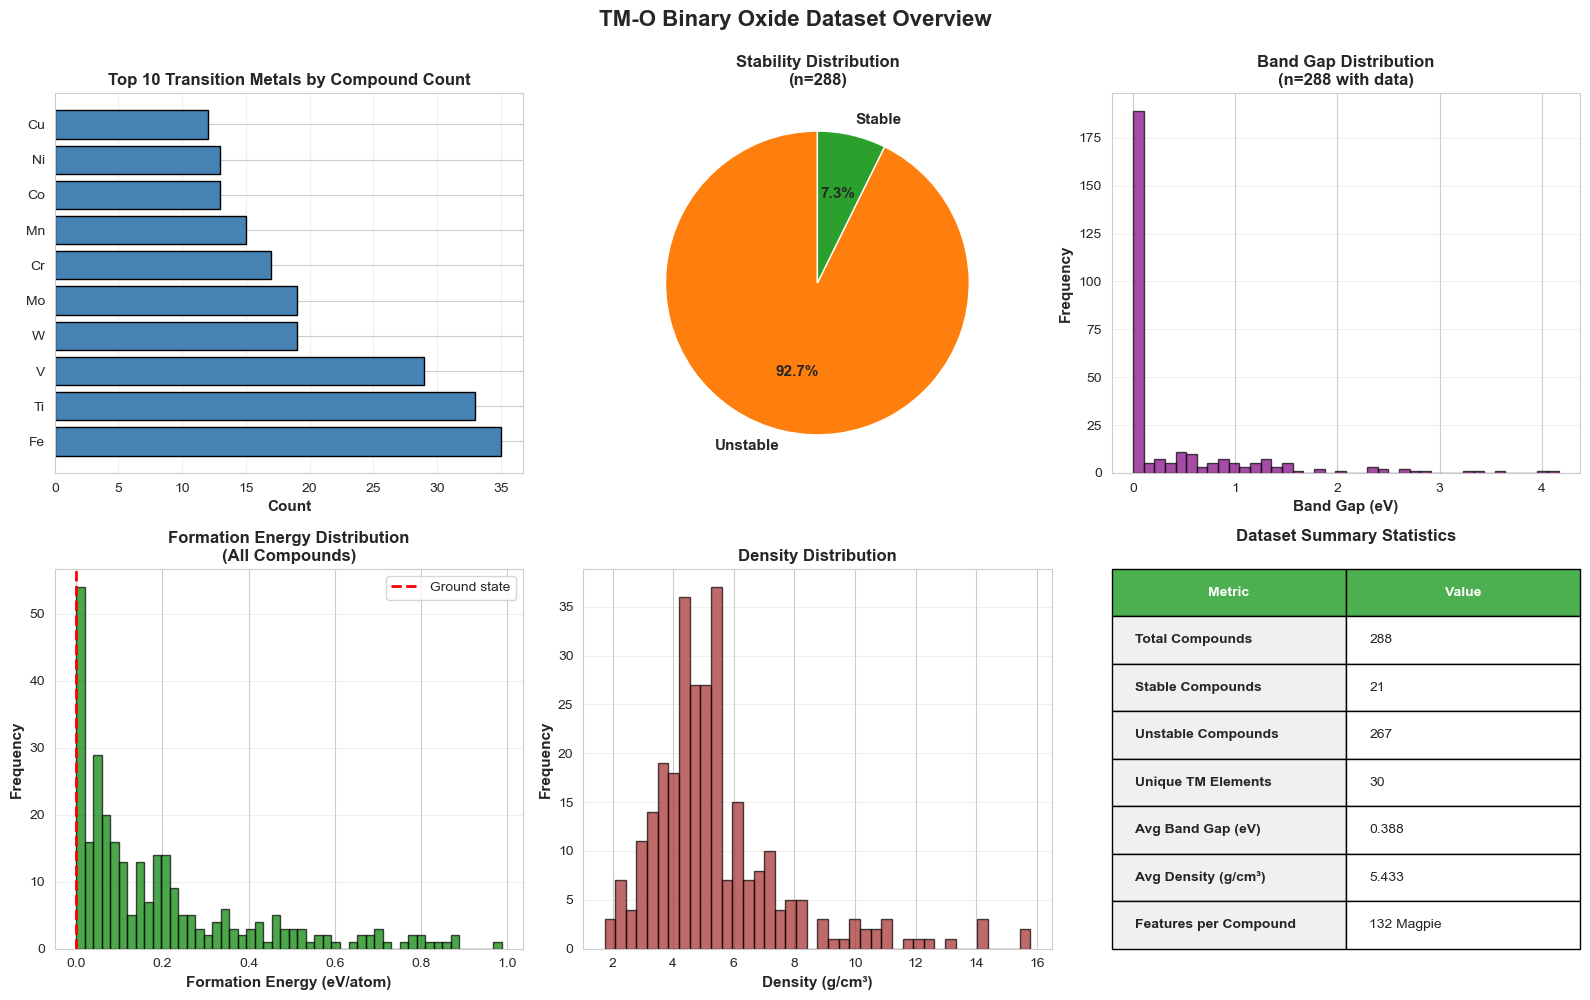

In [4]:
df_original = pd.read_csv(DATA_DIR / 'tm_oxygen_binary_compounds.csv')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Total compounds by transition metal
ax = axes[0, 0]
tm_counts = df_original['transition_metal'].value_counts().sort_values(ascending=False).head(10)
ax.barh(range(len(tm_counts)), tm_counts.values, color='steelblue', edgecolor='black')
ax.set_yticks(range(len(tm_counts)))
ax.set_yticklabels(tm_counts.index, fontsize=10)
ax.set_xlabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Top 10 Transition Metals by Compound Count', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# 2. Stability distribution
ax = axes[0, 1]
stability_counts = df_original['is_stable'].value_counts()
colors_pie = ['#ff7f0e', '#2ca02c']
wedges, texts, autotexts = ax.pie([stability_counts[False], stability_counts[True]], 
                                    labels=['Unstable', 'Stable'],
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title(f'Stability Distribution\n(n={len(df_original)})', fontsize=12, fontweight='bold')

# 3. Band gap distribution
ax = axes[0, 2]
band_gap_valid = df_original[df_original['band_gap'] != -1]['band_gap']
ax.hist(band_gap_valid, bins=40, color='purple', edgecolor='black', alpha=0.7)
ax.set_xlabel('Band Gap (eV)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title(f'Band Gap Distribution\n(n={len(band_gap_valid)} with data)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 4. Formation energy distribution
ax = axes[1, 0]
ax.hist(df_original['energy_above_hull'], bins=50, color='green', edgecolor='black', alpha=0.7)
ax.set_xlabel('Formation Energy (eV/atom)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Formation Energy Distribution\n(All Compounds)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ground state')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 5. Density distribution
ax = axes[1, 1]
ax.hist(df_original['density'], bins=40, color='brown', edgecolor='black', alpha=0.7)
ax.set_xlabel('Density (g/cm³)', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Density Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 6. Summary statistics table
ax = axes[1, 2]
ax.axis('off')
summary_stats = [
    ['Total Compounds', f"{len(df_original)}"],
    ['Stable Compounds', f"{df_original['is_stable'].sum()}"],
    ['Unstable Compounds', f"{(~df_original['is_stable']).sum()}"],
    ['Unique TM Elements', f"{df_original['transition_metal'].nunique()}"],
    ['Avg Band Gap (eV)', f"{band_gap_valid.mean():.3f}"],
    ['Avg Density (g/cm³)', f"{df_original['density'].mean():.3f}"],
    ['Features per Compound', '132 Magpie'],
]

table = ax.table(cellText=summary_stats, colLabels=['Metric', 'Value'],
                cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
for i in range(2):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(summary_stats) + 1):
    table[(i, 0)].set_facecolor('#f0f0f0')
    table[(i, 0)].set_text_props(weight='bold')

ax.set_title('Dataset Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.suptitle('TM-O Binary Oxide Dataset Overview', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("../figures/dataset_overview.png", dpi=100, bbox_inches="tight")
plt.show()

## Summary Table

In [9]:
export_results = df_cv_results.copy()
export_results = export_results[['Model', 'Test_Accuracy', 'Test_F1', 'Test_AUC', 'Test_Precision', 'Test_Recall']]
export_results.columns = ['Model', 'Accuracy', 'F1 Score', 'AUC-ROC', 'Precision', 'Recall']

# Round to 4 decimal places
for col in ['Accuracy', 'F1 Score', 'AUC-ROC', 'Precision', 'Recall']:
    export_results[col] = export_results[col].apply(lambda x: f'{x:.4f}')

export_results = export_results.sort_values('F1 Score', ascending=False)

print("\n" + "=" * 80)
print("FINAL RESULTS TABLE (for paper/presentation)")
print("=" * 80 + "\n")
print(export_results.to_string(index=False))

# Save as clean CSV
export_file = DATA_DIR / 'four_model_results_table.csv'
export_results.to_csv(export_file, index=False)
print(f"\nExported to {export_file}")


FINAL RESULTS TABLE (for paper/presentation)

                  Model Accuracy F1 Score AUC-ROC Precision Recall
Random Forest (Shallow)   0.8993   0.2956  0.7046    0.3086 0.3300
    Logistic Regression   0.7848   0.2112  0.5861    0.1573 0.4033
      Gradient Boosting   0.8994   0.2032  0.6942    0.3667 0.1633
 Random Forest (Medium)   0.9132   0.1738  0.7114    0.1833 0.1733

Exported to ../data/four_model_results_table.csv


## Random vs GroupKFold Comparison With and Without Structural Features

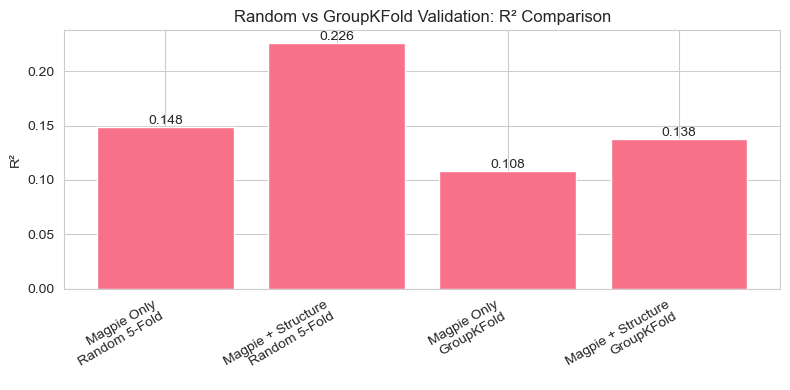

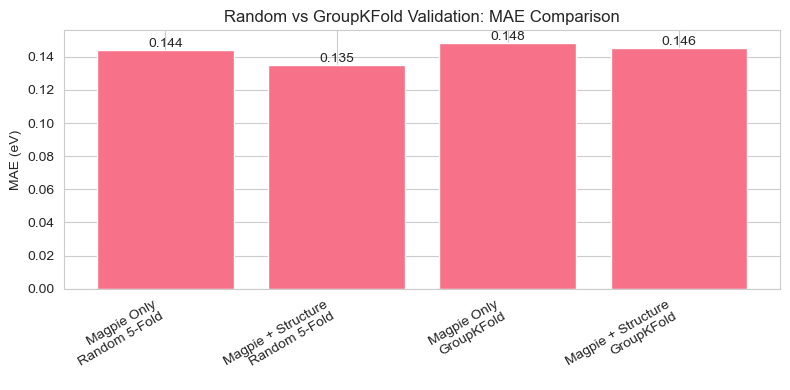

In [6]:
results_df = pd.read_csv("../data/model_comparison_results.csv")

plt.figure(figsize=(8,4))

plt.bar(
    results_df["Model"] + "\n" + results_df["Validation"],
    results_df["R2"]
)

plt.ylabel("R²")
plt.title("Random vs GroupKFold Validation: R² Comparison")

for i, value in enumerate(results_df["R2"]):
    plt.text(
        i,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/structural_R2_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8,4))

plt.bar(
    results_df["Model"] + "\n" + results_df["Validation"],
    results_df["MAE_eV"]
)

plt.ylabel("MAE (eV)")
plt.title("Random vs GroupKFold Validation: MAE Comparison")

for i, value in enumerate(results_df["MAE_eV"]):
    plt.text(
        i,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/structural_MAE_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

## Parity Plot of Magpie + Structure Random 5-Fold

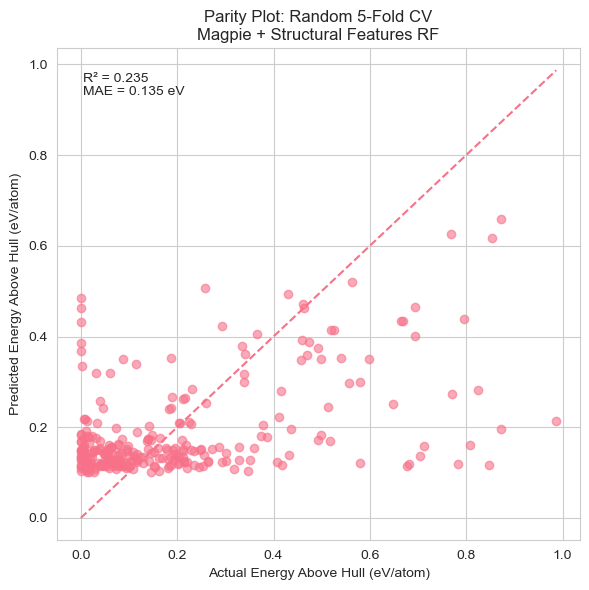

In [7]:
#Parity plot of the magpie + structure random split 5-fold CV, which had the best R2

from sklearn.metrics import r2_score, mean_absolute_error

# Load predictions
parity_df = pd.read_csv(
    "../data/random_magpie_structure_predictions.csv"
)

y_true = parity_df["Actual"]
y_pred = parity_df["Predicted"]


# Calculate metrics
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)


# -------------------------------
# Parity plot
# -------------------------------

plt.figure(figsize=(6,6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.6
)

# 1:1 line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)


plt.xlabel("Actual Energy Above Hull (eV/atom)")
plt.ylabel("Predicted Energy Above Hull (eV/atom)")

plt.title(
    "Parity Plot: Random 5-Fold CV\nMagpie + Structural Features RF"
)


# Add metrics
plt.text(
    0.05,
    0.95,
    f"R² = {r2:.3f}\nMAE = {mae:.3f} eV",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)


plt.tight_layout()

plt.savefig(
    "random_magpie_structure_parity.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()

## Importances Plot

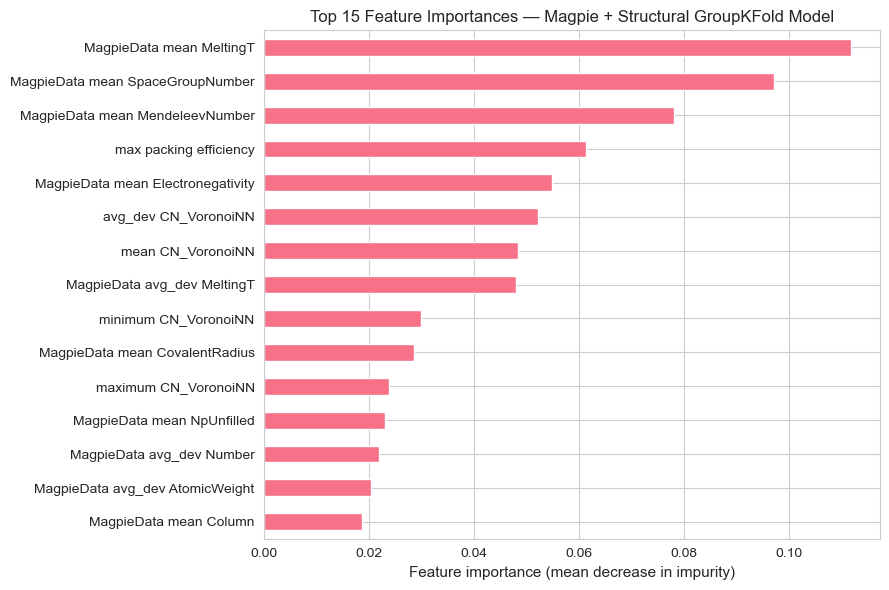

In [8]:
importances = pd.read_csv("../data/importances.csv")
top15 = importances.head(15).copy()
top15 = top15.set_index("Feature")

fig, ax = plt.subplots(figsize=(9, 6))

top15["Importance"].plot(
    kind="barh",
    ax=ax
)

ax.invert_yaxis()
ax.set_xlabel(
    "Feature importance (mean decrease in impurity)",
    fontsize=11
)
ax.set_ylabel("")
ax.set_title(
    "Top 15 Feature Importances — Magpie + Structural GroupKFold Model",
    fontsize=12
)

plt.tight_layout()
plt.savefig(
    "importances.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()